In [14]:
"""
CSC423 NATURAL LANGUAGE PROCESSING PROJECT

Kenyan Language Identification System

Languages:
- Swahili
- Sheng
- English
- Luo

Objective:
Build a machine
learning system capable of identifying the
language of a given text input using NLP techniques.

Author: valentine Paul
"""

'\nCSC423 NATURAL LANGUAGE PROCESSING PROJECT\n\nKenyan Language Identification System\n\nLanguages:\n- Swahili\n- Sheng\n- English\n- Luo\n\nObjective:\nBuild a machine\nlearning system capable of identifying the\nlanguage of a given text input using NLP techniques.\n\nAuthor: valentine Paul\n'

In [15]:
# Install required libraries if not installed
!pip install pandas numpy scikit-learn nltk matplotlib seaborn joblib


In [16]:
# Core libraries
import pandas as pd
import numpy as np

# Text processing
import re
import nltk

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

In [17]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
# Load dataset

data = pd.read_csv("dataset.csv")

# Preview dataset
data.head()

,text\tlanguage
0,niko job leo\tswahili
1,ninapenda party sana\tswahili
2,tunakutana kibanda jioni\tswahili
3,tunakutana kibanda jioni\tswahili
4,niko naenda base\tswahili


In [29]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nDataset Info:")
print(data.info())

Dataset Shape:
(2000, 1)

Column Names:
Index(['text\tlanguage'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text	language  2000 non-null   object
dtypes: object(1)
memory usage: 15.8+ KB
None


In [30]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
text\tlanguage    0
dtype: int64


In [37]:
print("Language Distribution:")
print(data["text\tlanguage"].value_counts())

Language Distribution:
text\tlanguage
waneno e market\tluo                    14
let us go to the school\tenglish        12
the party is interesting\tenglish       12
kazi en maber\tluo                      11
an gi tich e town\tluo                  11
                                        ..
we saw the party yesterday\tenglish      1
the kazi is interesting\tenglish         1
we will meet at the kibanda\tenglish     1
we saw the food yesterday\tenglish       1
wan bedo e job\tluo                      1
Name: count, Length: 396, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


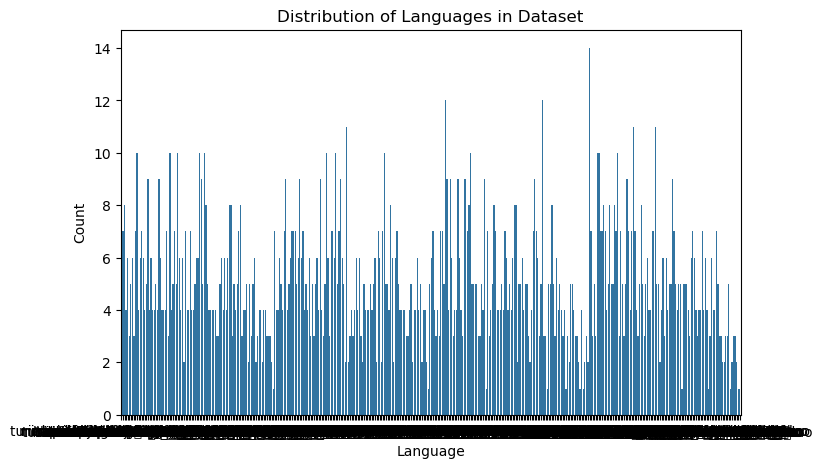

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="text\tlanguage")

plt.title("Distribution of Languages in Dataset")

plt.xlabel("Language")

plt.ylabel("Count")

plt.show()

In [40]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra spaces
    text = re.sub("\s+", " ", text)
    
    return text

In [42]:
data["clean_text"] = data["text\tlanguage"].apply(clean_text)

data.head()

,text\tlanguage,clean_text
0,niko job leo\tswahili,niko job leo swahili
1,ninapenda party sana\tswahili,ninapenda party sana swahili
2,tunakutana kibanda jioni\tswahili,tunakutana kibanda jioni swahili
3,tunakutana kibanda jioni\tswahili,tunakutana kibanda jioni swahili
4,niko naenda base\tswahili,niko naenda base swahili


In [43]:
data["text_length"] = data["clean_text"].apply(len)

data.head()

,text\tlanguage,clean_text,text_length
0,niko job leo\tswahili,niko job leo swahili,20
1,ninapenda party sana\tswahili,ninapenda party sana swahili,28
2,tunakutana kibanda jioni\tswahili,tunakutana kibanda jioni swahili,32
3,tunakutana kibanda jioni\tswahili,tunakutana kibanda jioni swahili,32
4,niko naenda base\tswahili,niko naenda base swahili,24


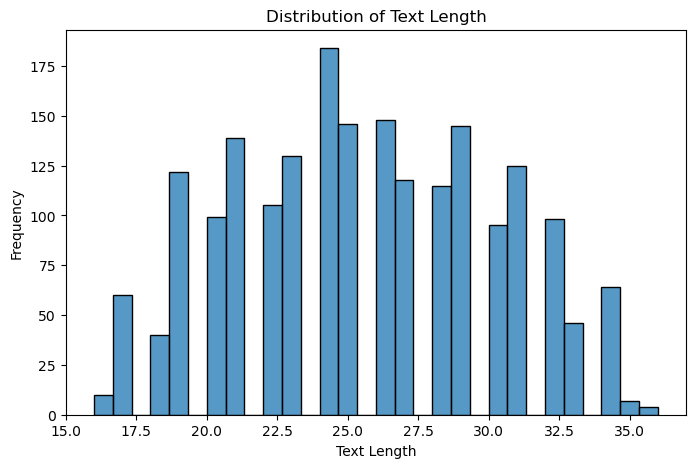

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(data["text_length"], bins=30)

plt.title("Distribution of Text Length")

plt.xlabel("Text Length")

plt.ylabel("Frequency")

plt.show()

In [45]:
vectorizer = TfidfVectorizer(

    analyzer="char",

    ngram_range=(2,4),

    max_features=10000

)

In [47]:
X = vectorizer.fit_transform(data["clean_text"])

y = data["text\tlanguage"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [49]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [50]:
print("Naive Bayes Accuracy:")

print(accuracy_score(y_test, nb_predictions))

print("\nClassification Report:")

print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy:
0.325

Classification Report:
                                     precision    recall  f1-score   support

                 adhi base kiny	luo       0.00      0.00      0.00         1
                adhi field kiny	luo       0.14      1.00      0.25         1
               adhi market kiny	luo       0.00      0.00      0.00         1
               adhi office kiny	luo       0.00      0.00      0.00         4
               adhi school kiny	luo       0.00      0.00      0.00         1
               adhi tich e base	luo       0.00      0.00      0.00         2
             adhi tich e center	luo       0.12      1.00      0.22         1
            adhi tich e kibanda	luo       0.00      0.00      0.00         2
             adhi tich e market	luo       0.00      0.00      0.00         1
               adhi tich e soko	luo       0.00      0.00      0.00         1
              an gi tich e base	luo       1.00      1.00      1.00         1
            an gi tich 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique c

In [51]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

In [52]:
print("SVM Accuracy:")

print(accuracy_score(y_test, svm_predictions))

print("\nClassification Report:")

print(classification_report(y_test, svm_predictions))

SVM Accuracy:
0.98

Classification Report:
                                     precision    recall  f1-score   support

                 adhi base kiny	luo       1.00      1.00      1.00         1
                adhi field kiny	luo       1.00      1.00      1.00         1
               adhi market kiny	luo       1.00      1.00      1.00         1
               adhi office kiny	luo       0.67      1.00      0.80         4
               adhi school kiny	luo       1.00      1.00      1.00         1
               adhi tich e base	luo       1.00      1.00      1.00         2
             adhi tich e center	luo       1.00      1.00      1.00         1
            adhi tich e kibanda	luo       1.00      1.00      1.00         2
             adhi tich e market	luo       1.00      1.00      1.00         1
               adhi tich e soko	luo       1.00      1.00      1.00         1
              an gi tich e base	luo       1.00      1.00      1.00         1
            an gi tich e center	

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The n

In [53]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [54]:
print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_predictions))

print("\nClassification Report:")

print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy:
0.5225

Classification Report:
                                     precision    recall  f1-score   support

                 adhi base kiny	luo       0.00      0.00      0.00         1
                adhi field kiny	luo       0.17      1.00      0.29         1
               adhi market kiny	luo       1.00      1.00      1.00         1
               adhi office kiny	luo       0.00      0.00      0.00         4
               adhi school kiny	luo       1.00      1.00      1.00         1
               adhi tich e base	luo       0.00      0.00      0.00         2
             adhi tich e center	luo       0.17      1.00      0.29         1
              adhi tich e field	luo       0.00      0.00      0.00         0
            adhi tich e kibanda	luo       0.00      0.00      0.00         2
             adhi tich e market	luo       0.00      0.00      0.00         1
               adhi tich e soko	luo       0.00      0.00      0.00         1
              

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique c

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes 

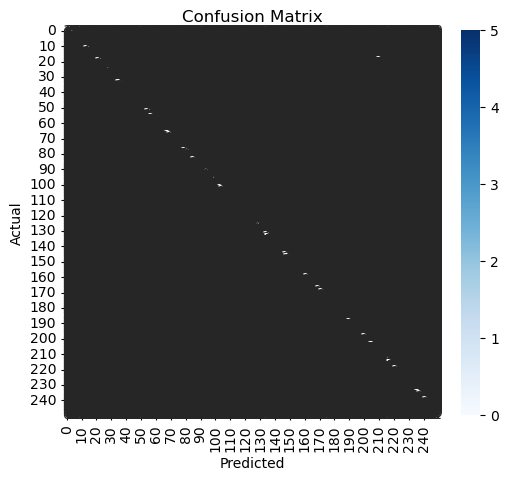

In [55]:
cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Model": ["Naive Bayes", "SVM", "Logistic Regression"],

    "Accuracy": [

        accuracy_score(y_test, nb_predictions),

        accuracy_score(y_test, svm_predictions),

        accuracy_score(y_test, lr_predictions)

    ]

})

results

In [57]:
results = pd.DataFrame({

    "Model": ["Naive Bayes", "SVM", "Logistic Regression"],

    "Accuracy": [

        accuracy_score(y_test, nb_predictions),

        accuracy_score(y_test, svm_predictions),

        accuracy_score(y_test, lr_predictions)

    ]

})

results

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The n

,Model,Accuracy
0,Naive Bayes,0.3250
1,SVM,0.9800
2,Logistic Regression,0.5225


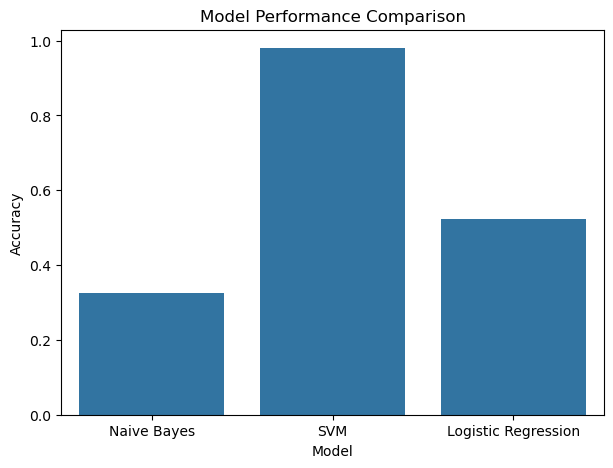

In [58]:
plt.figure(figsize=(7,5))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Model Performance Comparison")

plt.show()

In [59]:
best_model = svm_model

In [60]:
joblib.dump(best_model, "language_model.pkl")

['language_model.pkl']

In [61]:
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [62]:
model = joblib.load("language_model.pkl")

vectorizer = joblib.load("vectorizer.pkl")

In [63]:
def predict_language(text):

    text = clean_text(text)

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)

    return prediction[0]

In [64]:
print(predict_language("Niko soko leo"))

niko soko leo	swahili


In [65]:
print(predict_language("Wacha tuende base"))

print(predict_language("I am going to school"))

print(predict_language("An gi tich matek"))

wacha tuende base	sheng
i am going to the school	english
an gi tich e town	luo


In [66]:
user_input = input("Enter text: ")

print("Predicted Language:")

print(predict_language(user_input))

Enter text:  ninaenda soko


Predicted Language:
niko naenda soko	swahili


In [67]:
data.to_csv("clean_language_dataset.csv", index=False)